## **Step 1: Mount Google Drive**

In [1]:
# from google.colab import drive

# drive.mount('/content/drive')

## **Step 2: Set Dataset Path**

In [2]:
# dataset_path = "/content/drive/MyDrive/Uni Life/Junior/3rd Term/Deep Learning/Project/Dataset"

dataset_path = "/Users/leonmarco/Downloads/Dataset 2"

## **Step 3: Import Libraries**

In [3]:
%pip install tensorflow matplotlib

Note: you may need to restart the kernel to use updated packages.


In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter

## **Step 4: Prepare Image Dataset**

In [5]:
def random_blur(image):
    if np.random.random() < 0.3:            # 30% chance
        sigma = np.random.uniform(0.5, 1.0) # mild blur
        image = gaussian_filter(image, sigma=(sigma, sigma, 0))
    return image

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,

    # Color Jitter
    brightness_range=[0.8, 1.2],   # ±20% brightness
    channel_shift_range=30.0,      # subtle color/saturation shift

    # Horizontal Flip 
    horizontal_flip=True,          # 50% probability (default)

    # Mild Rotation
    rotation_range=10,             # max ±10° for natural head tilts

    # Safety: explicit fill for rotation gaps
    fill_mode='nearest',
)

# VALIDATION generator — NO augmentations, only rescaling
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
)


## **Step 5: Load Training Dataset**

In [6]:
train_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True,
)

Found 508 images belonging to 3 classes.


## **Step 6: Load Validation Dataset**

In [7]:
validation_data = val_datagen.flow_from_directory(
    dataset_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
)

Found 127 images belonging to 3 classes.


## **Step 7: Build Simple CNN**

In [8]:
model = models.Sequential()

model.add(layers. Conv2D(32, (3,3),
                         activation="relu",
                         input_shape=(128,128,3)))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(64, (3,3),
                        activation="relu"))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Flatten())
model.add(layers.Dense(64, activation="relu"))

model.add(layers.Dense(train_data.num_classes, 
                       activation="softmax"))

/opt/miniconda3/envs/ccmaclrl/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## **Step 8: Compile Model**

In [9]:
model.compile (
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## **Step 9: Train Model**

In [10]:
history = model.fit(
    train_data,
    epochs=12,
    validation_data=validation_data
)

Epoch 1/12
16/16 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.3760 - loss: 1.7477 - val_accuracy: 0.3701 - val_loss: 1.0994
Epoch 2/12
16/16 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.4193 - loss: 1.0804 - val_accuracy: 0.4173 - val_loss: 1.1156
Epoch 3/12
16/16 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.5413 - loss: 0.9273 - val_accuracy: 0.4961 - val_loss: 1.0783
Epoch 4/12
16/16 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.6142 - loss: 0.7516 - val_accuracy: 0.5197 - val_loss: 1.1167
Epoch 5/12
16/16 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.6752 - loss: 0.6239 - val_accuracy: 0.5591 - val_loss: 0.9216
Epoch 6/12
16/16 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.7165 - loss: 0.5529 - val_accuracy: 0.5276 - val_loss: 1.1772
Epoch 7/12
16/16 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.7756 - loss: 0.4775 - val_accuracy: 0.5197 - val_loss: 1.6157
Epoch 8/12
16/16 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.8130 - loss: 0.4400 - val_accuracy: 0.5354 - val_loss:

## **Step 10: Evaluate Model**

In [11]:
loss, accuracy = model.evaluate(validation_data)

print("Validation Accuracy: ", accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.5276 - loss: 2.0924
Validation Accuracy:  0.5275590419769287


## **Step 11: Plot Accuracy**

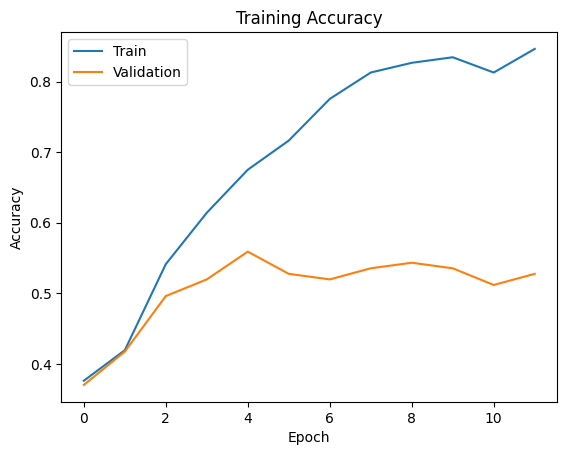

In [12]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

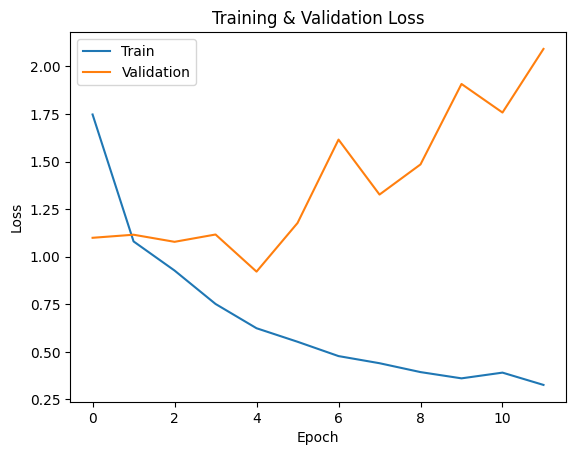

In [13]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

## **Step 12: Confusion Matrix**

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step


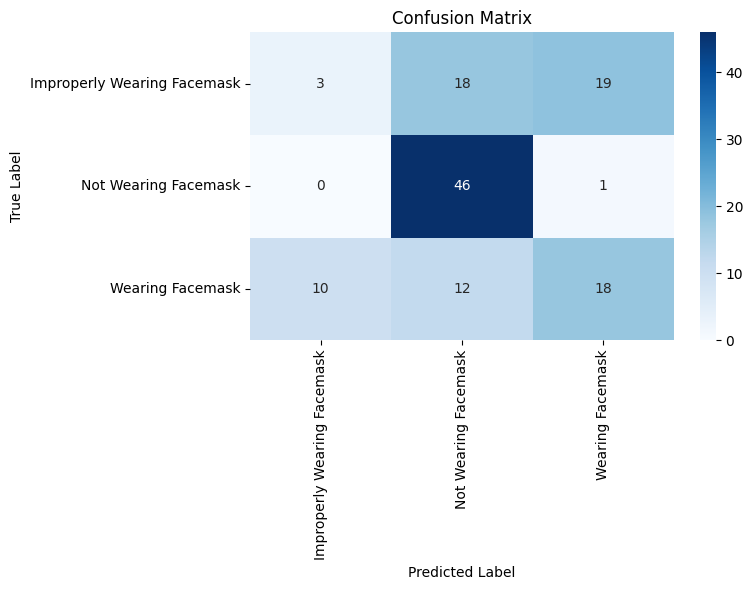


Classification Report:

                             precision    recall  f1-score   support

Improperly Wearing Facemask       0.23      0.07      0.11        40
       Not Wearing Facemask       0.61      0.98      0.75        47
           Wearing Facemask       0.47      0.45      0.46        40

                   accuracy                           0.53       127
                  macro avg       0.44      0.50      0.44       127
               weighted avg       0.45      0.53      0.46       127



In [14]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

validation_data.reset()  # Reset generator to start from beginning
y_pred_probs = model.predict(validation_data, steps=len(validation_data))
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = validation_data.classes

# Get class names (e.g., Masked, Unmasked, Improperly Worn)
class_names = list(train_data.class_indices.keys())

# Build the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=class_names, 
    yticklabels=class_names
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# Print detailed classification report (precision, recall, f1-score)
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))